# PCHN63... Workshop: Clustered Longitudinal Data Example

In [1]:
library('lattice')   # plotting functions
library('Matrix')    # covariance extraction and visualisation
library('nlme')      # mixed-effects modelling
library('car')       # Asymptotic ANOVA tests
library('emmeans')   # Follow-up tests
library('effects')   # Effects plots from the model
source('plot-lme.R') # custom plot.lme() function for making assumptions plots

Loading required package: carData
Welcome to emmeans.
Caution: You lose important information if you filter this package's results.
See '? untidy'
Use the command
    lattice::trellis.par.set(effectsTheme())
  to customize lattice options for effects plots.
See ?effectsTheme for details.


## The Dental Veneer Data

In [2]:
veneer <- read.table('veneer.dat', header=TRUE)
veneer[1:24,]

   patient tooth age base_gcf       cda time gcf
1        1     6  46       17  4.666667    3  11
2        1     6  46       17  4.666667    6  68
3        1     7  46       22  4.666667    3  13
4        1     7  46       22  4.666667    6  47
5        1     8  46       18  5.000000    3  14
6        1     8  46       18  5.000000    6  58
7        1     9  46       12  3.333333    3  10
8        1     9  46       12  3.333333    6  57
9        1    10  46       10  8.666667    3  14
10       1    10  46       10  8.666667    6  44
11       1    11  46       17  5.666667    3  11
12       1    11  46       17  5.666667    6  53
13       3     6  32        3  7.666667    3  28
14       3     6  32        3  7.666667    6  23
15       3     7  32        4 11.000000    3  17
16       3     7  32        4 11.000000    6  15
17       3     8  32        3 10.666670    3  19
18       3     8  32        3 10.666670    6  32
19       3     9  32       10 10.000000    3  34
20       3     9  32

In [3]:
veneer$patient <- as.factor(veneer$patient)
veneer$tooth   <- as.factor(veneer$tooth)

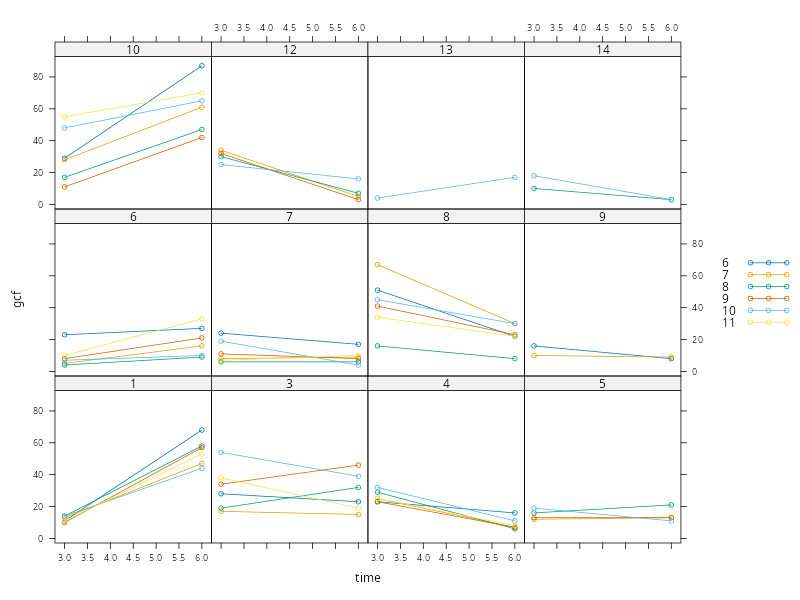

In [4]:
xyplot(
  gcf ~ time|patient, # x-axis=age, panel=SICDEG
  groups = tooth,   # separate lines per-child
  data   = veneer,    # data
  type   = "b",       # lines with points
  auto.key = TRUE
)

- Patient
    - `patient`: the unique identifier of each *patient*
    - `age`: the patient's age
- Tooth
    - `tooth`: the unique identifier of each *tooth*
    - `based_cdf`: the baseline measure of GCF for that tooth
    - `cda`: the ... for that tooth
- Longitudinal Measurements
    - `time`: the time in months after fitting the veneer
    - `gcf`: **the measurement of GCF at that time point**

## Model Building
To build a model of this dataset, we use the 3-step procedure outlined in the lesson. We assume at this point that the data has been investigated, wrangled, cleaned and ready for modelling.

### Step I: A Single Dependency Structure
We start by isolating a single dependency structure. This needs to be at the *lowest* level, with no further dependency structures within. In this example, this is a single *tooth* from a single *patient*. We choose `tooth == '6'` within `patient == '1'` for this purpose.

In [5]:
patient.1 <- subset(veneer,    patient == '1')
tooth.6   <- subset(patient.1, tooth   == '6')

print(tooth.6)

  patient tooth age base_gcf      cda time gcf
1       1     6  46       17 4.666667    3  11
2       1     6  46       17 4.666667    6  68


In [6]:
tooth.6 <- subset(patient.1, tooth == '6', select=c(-patient,-age,-base_gcf,-cda))
print(tooth.6)

  tooth time gcf
1     6    3  11
2     6    6  68


Based on this, our basic model for a single tooth is

$$
\text{GCF}_{i} = \beta_{0} + (\beta_{1} \times \text{time}_{i}) + \eta_{i}
$$

where $i$ indexes *time*. Already, a problem should be visible. As we only have two measurements per-tooth, the model fit will be perfect and there will be no residual variance left.

In [7]:
tooth.6.lm <- lm(gcf ~ 1 + time, data=tooth.6)
summary(tooth.6.lm)


Call:
lm(formula = gcf ~ 1 + time, data = tooth.6)

Residuals:
ALL 2 residuals are 0: no residual degrees of freedom!

Coefficients:
            Estimate Std. Error t value Pr(>|t|)
(Intercept)      -46        NaN     NaN      NaN
time              19        NaN     NaN      NaN

Residual standard error: NaN on 0 degrees of freedom
Multiple R-squared:      1,	Adjusted R-squared:    NaN 
F-statistic:   NaN on 1 and 0 DF,  p-value: NA


This means that we will not be able to estimate a unique effect of `time` for each tooth from each `patient`. Instead, we will need to *pool* information *across* patients. This is a constraint of the data that we will need to bear in mind.

### Step II: Expand to Multiple Structures
In our second step, we expand the model above to *multiple* teeth from the same patient. We index these using the notation of $(t)$, to indicate which terms *belong* to a particular *tooth*. We start with the most general case of allowing every term to vary by-tooth, giving us

$$
\text{GCF}^{(t)}_{i} = \beta_{0}^{(t)} + \left(\beta^{(t)}_{1} \times \text{time}_{i}\right) + \eta^{(t)}_{i}.
$$

We can now reason more carefully about each of these.



In [8]:
print(patient.1)

   patient tooth age base_gcf      cda time gcf
1        1     6  46       17 4.666667    3  11
2        1     6  46       17 4.666667    6  68
3        1     7  46       22 4.666667    3  13
4        1     7  46       22 4.666667    6  47
5        1     8  46       18 5.000000    3  14
6        1     8  46       18 5.000000    6  58
7        1     9  46       12 3.333333    3  10
8        1     9  46       12 3.333333    6  57
9        1    10  46       10 8.666667    3  14
10       1    10  46       10 8.666667    6  44
11       1    11  46       17 5.666667    3  11
12       1    11  46       17 5.666667    6  53


### Step III: Write the Higher-level Models
Now that we have made a decision about all the Level 1 terms, we can write the Level 2 models for each term...

$$
\begin{alignat*}{1}
\text{Level 1 (Longitudinal)} \\
    \text{GCF}^{(t)}_{i} &= \beta_{0}^{(t)} + \left(\beta^{(t)}_{1} \times \text{time}_{i}\right) + \eta^{(t)}_{i}. \\ \quad \\
\text{Level 2 (Tooth)} \\
    \beta_{0}^{(t)} &= \beta_{0} + \left(\beta_{2} \times \text{GCFb}^{(t)}\right) + \left(\beta_{3} \times \text{CDA}^{(t)}\right) + \xi_{0}^{(t)} \\
    \beta^{(t)}_{1} &= \beta_{1} \\
\end{alignat*}
$$

... we can add interactions with the effect of time in the model for $\beta^{(t)}_{1}$ ...

$$
\begin{alignat*}{1}
\text{Level 1 (Longitudinal)} \\
    \text{GCF}^{(t)}_{i} &= \beta_{0}^{(t)} + \left(\beta^{(t)}_{1} \times \text{time}_{i}\right) + \eta^{(t)}_{i}. \\ \quad \\
\text{Level 2 (Tooth)} \\
    \beta_{0}^{(t)} &= \beta_{0} + \left(\beta_{2} \times \text{GCFb}^{(t)}\right) + \left(\beta_{3} \times \text{CDA}^{(t)}\right) + \xi_{0}^{(t)} \\
    \beta^{(t)}_{1} &= \beta_{1} + \left(\beta_{4} \times \text{GCFb}^{(t)}\right) + \left(\beta_{5} \times \text{CDA}^{(t)}\right)  \\
\end{alignat*}
$$

#### Expand to Multiple Patients

$$
\begin{alignat*}{1}
\text{Level 2 (Tooth)} \\
    \beta_{0}^{(t)} &= \beta^{(p)}_{0} + \left(\beta^{(p)}_{2} \times \text{GCFb}^{(t)}\right) + \left(\beta^{(p)}_{3} \times \text{CDA}^{(t)}\right) + \xi_{0}^{(t)} \\
    \beta^{(t)}_{1} &= \beta^{(p)}_{1} + \left(\beta^{(p)}_{4} \times \text{GCFb}^{(t)}\right) + \left(\beta^{(p)}_{5} \times \text{CDA}^{(t)}\right) \\ \quad \\
\text{Level 3 (Patient)} \\
    \beta^{(p)}_{0} &= \beta_{0} + \left(\beta_{6} \times \text{age}^{(p)}\right) + \phi_{0}^{(p)} \\
    \beta^{(p)}_{1} &= \beta_{1} + \left(\beta_{7} \times \text{age}^{(p)}\right) + \phi_{1}^{(p)} \\
    \beta^{(p)}_{2} &= \beta_{2}  \\
    \beta^{(p)}_{3} &= \beta_{3} \\
    \beta^{(p)}_{4} &= \beta_{4} \\
    \beta^{(p)}_{5} &= \beta_{5} 
\end{alignat*}
$$

... The full model is

$$
\begin{alignat*}{1}
\text{Level 1 (Longitudinal)} \\
    \text{GCF}^{(t)}_{i} &= \beta_{0}^{(t)} + \left(\beta^{(t)}_{1} \times \text{time}_{i}\right) + \eta^{(t)}_{i}. \\ \quad \\
\text{Level 2 (Tooth)} \\
    \beta_{0}^{(t)} &= \beta^{(p)}_{0} + \left(\beta^{(p)}_{2} \times \text{GCFb}^{(t)}\right) + \left(\beta^{(p)}_{3} \times \text{CDA}^{(t)}\right) + \xi_{0}^{(t)} \\
    \beta^{(t)}_{1} &= \beta^{(p)}_{1} + \left(\beta^{(p)}_{4} \times \text{GCFb}^{(t)}\right) + \left(\beta^{(p)}_{5} \times \text{CDA}^{(t)}\right) \\ \quad \\
\text{Level 3 (Patient)} \\
    \beta^{(p)}_{0} &= \beta_{0} + \left(\beta_{6} \times \text{age}^{(p)}\right) + \phi_{0}^{(p)} \\
    \beta^{(p)}_{1} &= \beta_{1} + \left(\beta_{7} \times \text{age}^{(p)}\right) + \phi_{1}^{(p)} \\
    \beta^{(p)}_{2} &= \beta_{2}  \\
    \beta^{(p)}_{3} &= \beta_{3} \\
    \beta^{(p)}_{4} &= \beta_{4} \\
    \beta^{(p)}_{5} &= \beta_{5} 
\end{alignat*}
$$

which we can simplify by collapsing the fixed-effects back into the different levels to give

$$
\begin{alignat*}{1}
\text{Level 1 (Longitudinal)} \\
    \text{GCF}^{(t)}_{i} &=  \\ \quad \\
\text{Level 2 (Tooth)} \\
    \beta_{0}^{(t)} &= \\ \quad \\
\text{Level 3 (Patient)} \\
    \beta^{(p)}_{0} &=  \\
    \beta^{(p)}_{1} &= 
\end{alignat*}
$$

## Fitting the Model in `R`

$$
\begin{alignat*}{1}
    \text{GCF}^{(t)}_{i} = &\: + \\
     &\xi_{0}^{(t)} + \phi_{0}^{(p)} + \left(\phi_{1}^{(p)} \times \text{time}_{i}\right) + \eta^{(t)}_{i}
\end{alignat*}
$$

$$
\begin{alignat*}{1}
    \xi_{0} &\:|\: t \\
    \phi_{0} + \left(\phi_{1} \times \text{time}_{i}\right) &\:|\: p \\
\end{alignat*}
$$

implying that we need both `1|tooth` and `1 + time|patient` in the model. 

How do we do this? The way `lme()` handles this situation is by passing a `list` to the `random=` option. Within this list, we label each field using the relevent factor variable and then give the model formula. Due to the labelling, the conditional syntax is implied and does not need to be given explicitly. So, for both `1|tooth` and `1 + time|patient` we can use `list(tooth = ~ 1, patient = ~ 1 + age)`. This gives us full control of the random-effects specification at each level. Our model can therefore be expressed to `lme()` uisng the following syntax

In [9]:
veneer.lme <- lme(fixed   = gcf ~ 1 + base_gcf + cda + time + age +
                                  time:base_gcf + time:cda + time:age,
                  random  = list(tooth   = ~ 1,
                                 patient = ~ 1 + time),
                  data    = veneer, 
                  control = lmeControl(opt='optim') 
) 

In [10]:
Sigma.1 <- try(getVarCov(veneer.lme))

Error in getVarCov.lme(veneer.lme) : 
  not implemented for multiple levels of nesting


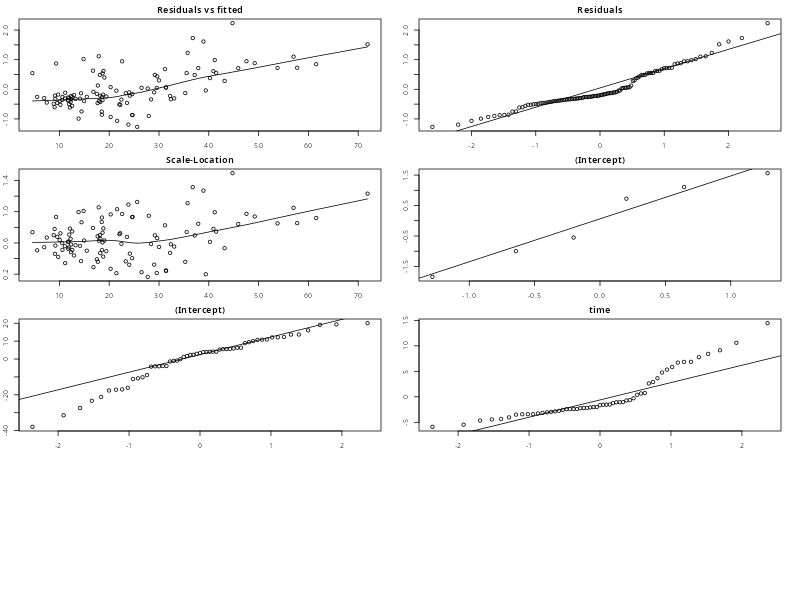

Warning message:
In plot.lme(veneer.lme) :
  Marginal covariance structure not available for more than 2 levels


In [11]:
plot.lme(veneer.lme)

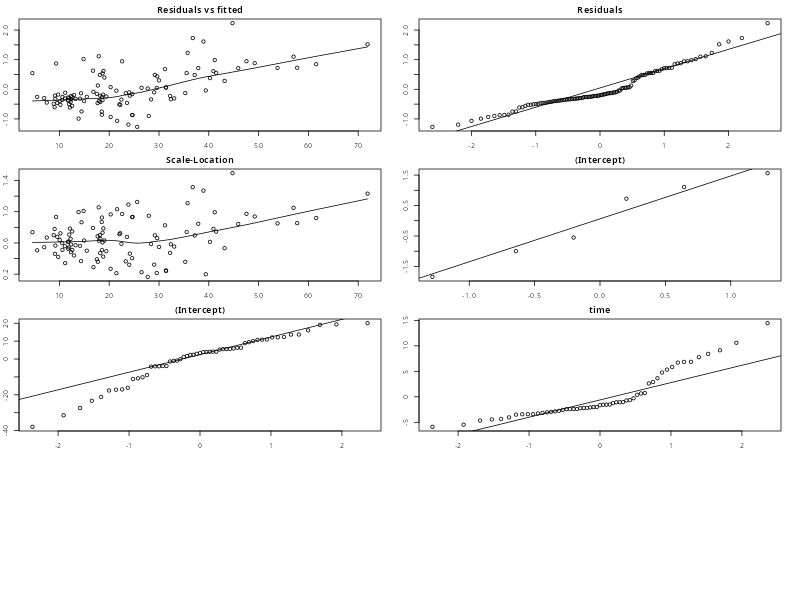

Warning message:
In plot.lme(veneer.lme) :
  Marginal covariance structure not available for more than 2 levels


In [12]:
veneer.lme <- lme(fixed   = gcf ~ 1 + base_gcf + cda + time + age +
                                  time:base_gcf + time:cda + time:age,
                  random  = list(tooth   = ~ 1,
                                 patient = ~ 1 + time),
                  data    = veneer, 
                  control = lmeControl(opt='optim') 
) 

plot.lme(veneer.lme)

In [13]:
Anova(veneer.lme)

Analysis of Deviance Table (Type II tests)

Response: gcf
                Chisq Df Pr(>Chisq)    
base_gcf       0.2237  1    0.63622    
cda            0.0008  1    0.97751    
time           0.6217  1    0.43041    
age           16.5425  1  4.757e-05 ***
base_gcf:time  0.2034  1    0.65197    
cda:time       2.7075  1    0.09988 .  
time:age       4.4098  1    0.03573 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

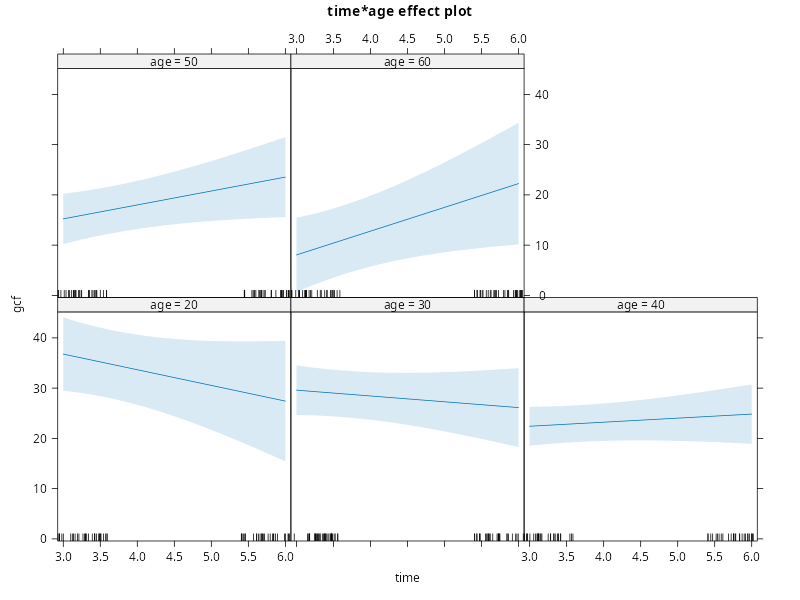

In [19]:
plot(effect('time:age', veneer.lme))